# Naive Bayes using Titanic Dataset

In [198]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [199]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [200]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [201]:
df.shape

(891, 15)

In [202]:
df.drop(columns=['sibsp', 'parch',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'], inplace=True)

In [203]:
df.head()

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [204]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
fare,0


In [205]:
df['age'].fillna(df['age'].mean(),inplace=True)

/tmp/ipykernel_1307/1492264711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [206]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
fare,0


In [207]:
df['sex'] = df['sex'].map({'male':1, 'female':0})
df.head()

,survived,pclass,sex,age,fare
0,0,3,1,22.0,7.2500
1,1,1,0,38.0,71.2833
2,1,3,0,26.0,7.9250
3,1,1,0,35.0,53.1000
4,0,3,1,35.0,8.0500


In [208]:
X = df.drop(columns=['survived'])
y = df['survived']
print(X.shape)
print(y.shape)


(891, 4)
(891,)


In [209]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [210]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [211]:
model_accuaracy = gnb.score(X_test,y_test)
model_accuaracy

0.7597765363128491

In [212]:
X_test.head(5)

,pclass,sex,age,fare
707,1,1,42.0,26.2875
37,3,1,21.0,8.0500
615,2,0,24.0,65.0000
169,3,1,28.0,56.4958
68,3,0,17.0,7.9250


In [213]:
model_pred = gnb.predict(X_test[:5])
model_pred

array([0, 0, 1, 0, 1])

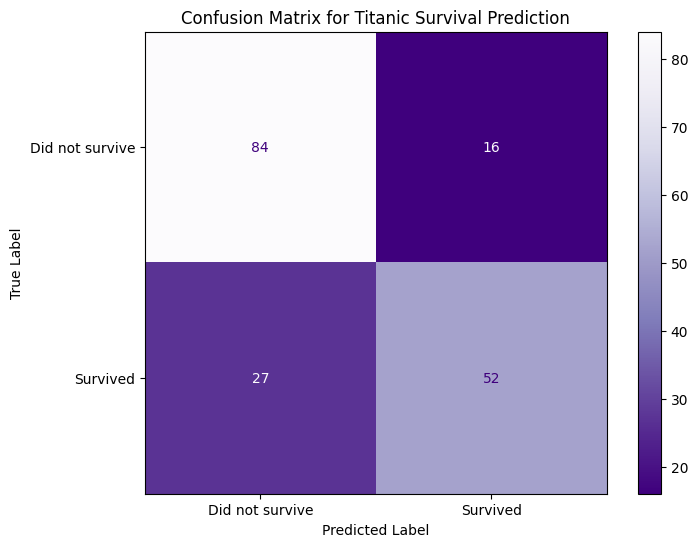

In [214]:
y_pred = gnb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
display_cm.plot(cmap=plt.cm.Purples_r, ax=ax)
plt.title('Confusion Matrix for Titanic Survival Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

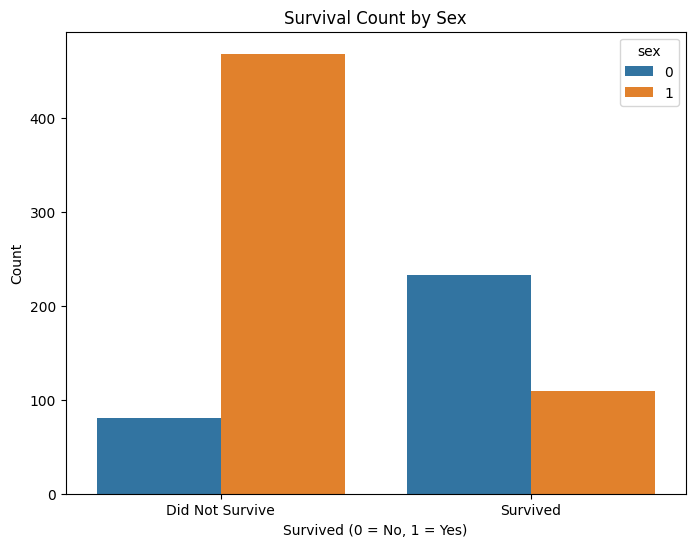

In [215]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='survived', hue='sex')
plt.title('Survival Count by Sex')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

# Naive Bayes using Wine Dataset

In [216]:
wine_df = pd.read_csv('/content/WineQT.csv')
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [217]:
wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [218]:
wine_df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [219]:
X = wine_df.drop(columns=['quality','Id'])
y = wine_df['quality']

In [220]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [221]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [222]:
model_accuaracy = gnb.score(X_test,y_test)
model_accuaracy

0.5807860262008734

In [223]:
model_pred = gnb.predict(X_test[:5])
model_pred
#

array([6, 5, 5, 4, 7])

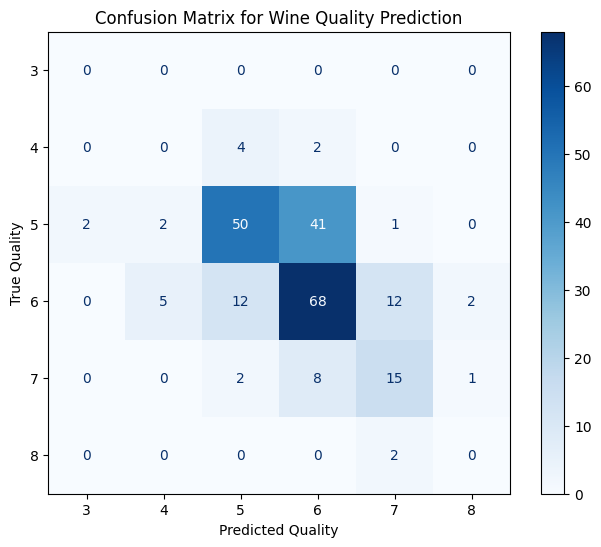

In [224]:
y_pred = gnb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(np.union1d(np.unique(y_test), np.unique(y_pred)))
)

display_cm.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Confusion Matrix for Wine Quality Prediction')
plt.xlabel('Predicted Quality')
plt.ylabel('True Quality')

plt.show()

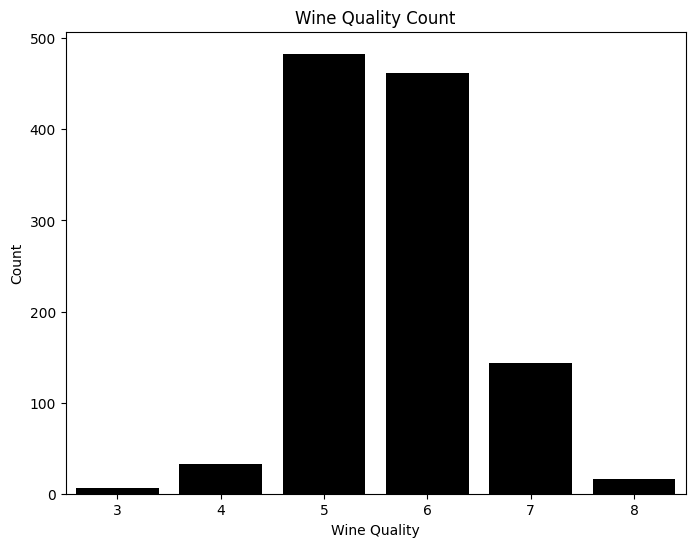

In [225]:
plt.figure(figsize=(8, 6))

sns.countplot(data=wine_df, x='quality',color='black')

plt.title('Wine Quality Count')
plt.xlabel('Wine Quality')
plt.ylabel('Count')

plt.show()

# Naive Bayes using Breast Cancer Dataset

In [226]:
cancer_df = pd.read_csv('/content/data.csv')
cancer_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [227]:
cancer_df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [228]:
cancer_df.drop(columns=['Unnamed: 32','id'],inplace=True)

In [229]:
cancer_df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [230]:
X = cancer_df.drop(columns=['diagnosis'])
y = cancer_df['diagnosis']

In [231]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [232]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [233]:
model_accuaracy = gnb.score(X_test,y_test)
model_accuaracy

0.9736842105263158

In [234]:
model_pred = gnb.predict(X_test[:5])
model_pred

array(['B', 'M', 'M', 'B', 'B'], dtype='<U1')

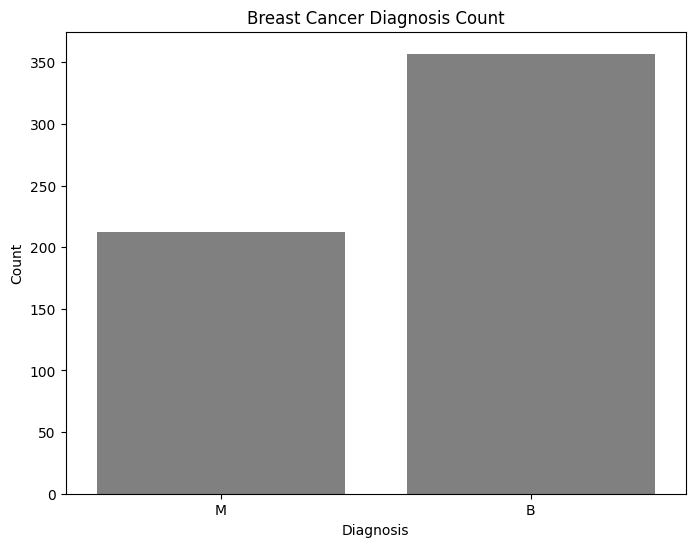

In [235]:
plt.figure(figsize=(8, 6))

sns.countplot(data=cancer_df, x='diagnosis',color='Grey')

plt.title('Breast Cancer Diagnosis Count')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

plt.show()

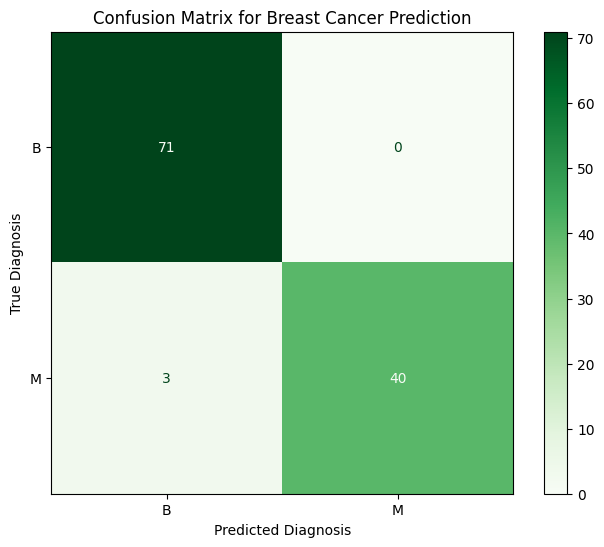

In [236]:
y_pred = gnb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(np.union1d(np.unique(y_test), np.unique(y_pred)))
)

display_cm.plot(cmap=plt.cm.Greens, ax=ax)

plt.title('Confusion Matrix for Breast Cancer Prediction')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('True Diagnosis')

plt.show()